# AnalyticGAN — Notebook 2: Data Preprocessor
**Goal:** Build the VGM encoder + one-hot pipeline that converts
raw tabular data into tensors the GAN can train on — and back again.
---

## 1. Install & Import Libraries

In [14]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import LabelEncoder
import warnings
import pickle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded.")

Libraries loaded.


## 2. Load Dataset

In [15]:
import os
from pathlib import Path

import pandas as pd
import kagglehub

# Reuse the same KaggleHub-based loader as 01_eda
TARGET_COL = "Class"

print("Downloading 'mlg-ulb/creditcardfraud' via kagglehub (or using cache)...")
dataset_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud")).resolve()
print("Dataset path:", dataset_dir)

print("\nSearching for 'creditcard.csv' in the dataset directory...")
csv_candidates = list(dataset_dir.rglob("creditcard.csv"))

if not csv_candidates:
    print("\nFiles found in dataset directory:")
    for p in dataset_dir.rglob("*"):
        if p.is_file():
            print(" -", p.relative_to(dataset_dir))
    raise FileNotFoundError(
        f"'creditcard.csv' was not found anywhere under:\n  {dataset_dir}\n"
        "Check the file listing above to see what was downloaded."
    )

csv_path = csv_candidates[0]
print(f"Found 'creditcard.csv' at: {csv_path}")

df = pd.read_csv(csv_path)
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset path: C:\Users\Owner\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3

Searching for 'creditcard.csv' in the dataset directory...
Found 'creditcard.csv' at: C:\Users\Owner\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 3. Column Type Detection
Automatically separate continuous vs categorical columns.

In [16]:
def detect_column_types(df, target_col, cat_threshold=10):
    """Auto-detect continuous vs categorical columns.

    Columns with <= cat_threshold unique values are treated as categorical.
    """
    continuous  = []
    categorical = []

    for col in df.columns:
        if col == target_col:
            continue
        if df[col].nunique() <= cat_threshold or df[col].dtype == object:
            categorical.append(col)
        else:
            continuous.append(col)

    return continuous, categorical


continuous_cols, categorical_cols = detect_column_types(df, TARGET_COL)

print(f"Continuous  ({len(continuous_cols)}): {continuous_cols[:5]} ...")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Target: {TARGET_COL}")

Continuous  (30): ['Time', 'V1', 'V2', 'V3', 'V4'] ...
Categorical (0): []
Target: Class


## 4. VGM Encoder — Core Concept
Each continuous column is modeled with a Bayesian Gaussian Mixture.
A value is encoded as:
- **normalized scalar** — how far it sits within its assigned mode
- **one-hot mode vector** — which Gaussian mode it belongs to

This lets the Generator learn multi-modal distributions properly.

In [17]:
class VGMEncoder:
    """Variational Gaussian Mixture encoder for a single continuous column.

    Encodes each value as (normalized_value, one_hot_mode).
    """

    def __init__(self, n_components=10, eps=0.005):
        self.n_components = n_components
        self.eps          = eps
        self.bgm = BayesianGaussianMixture(
            n_components=n_components,
            weight_concentration_prior_type="dirichlet_process",
            weight_concentration_prior=0.001,
            max_iter=100,
            random_state=42,
            n_init=1,
        )
        self.valid_components = None
        self.n_valid          = None

    def fit(self, data):
        """Fit BGM and identify active components (weight > eps)."""
        data = np.asarray(data).reshape(-1, 1)
        self.bgm.fit(data)
        self.valid_components = np.where(self.bgm.weights_ > self.eps)[0]
        self.n_valid          = len(self.valid_components)
        return self

    def transform(self, data):
        """Encode data -> (normalized_values, one_hot_modes).

        Output shape: (n_samples, 1 + n_valid_components)
        """
        data   = np.asarray(data).reshape(-1, 1)
        means  = self.bgm.means_[self.valid_components].flatten()
        stds   = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()

        # Posterior probability for each valid component
        probs = self.bgm.predict_proba(data)[:, self.valid_components]

        # Stochastically assign each point to a mode with safe normalization
        mode_idx = []
        for p in probs:
            s = p.sum()
            if s <= 0 or not np.isfinite(s):
                # Fallback to uniform over valid components
                p_norm = np.ones(self.n_valid, dtype=np.float64) / self.n_valid
            else:
                p_norm = (p / s).astype(np.float64)
            mode_idx.append(np.random.choice(self.n_valid, p=p_norm))
        mode_idx = np.array(mode_idx)

        # Normalize within the assigned mode
        sel_means  = means[mode_idx]
        sel_stds   = stds[mode_idx]
        normalized = (data.flatten() - sel_means) / (4 * sel_stds + 1e-8)
        normalized = np.clip(normalized, -0.99, 0.99)

        # One-hot encode the mode
        one_hot = np.zeros((len(data), self.n_valid), dtype=np.float32)
        one_hot[np.arange(len(data)), mode_idx] = 1

        return np.column_stack([normalized, one_hot]).astype(np.float32)

    def inverse_transform(self, encoded):
        """Decode (normalized_values, one_hot_modes) -> original scale values."""
        encoded    = np.asarray(encoded)
        means      = self.bgm.means_[self.valid_components].flatten()
        stds       = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        normalized = encoded[:, 0]
        one_hot    = encoded[:, 1:]
        mode_idx   = np.argmax(one_hot, axis=1)

        sel_means = means[mode_idx]
        sel_stds  = stds[mode_idx]

        return normalized * 4 * sel_stds + sel_means


print("VGMEncoder class defined.")

VGMEncoder class defined.


## 5. Full Preprocessor Pipeline
Wraps VGMEncoder (continuous) + one-hot (categorical) into a single
`fit → transform → inverse_transform` API.

In [18]:
class TabularPreprocessor:
    """Full preprocessing pipeline for tabular GAN training.

    - Continuous columns  → VGM encoding (scalar + one-hot mode)
    - Categorical columns → label + one-hot encoding
    - Target column       → stored as conditional vector

    Usage:
        prep = TabularPreprocessor()
        prep.fit(df, continuous_cols, categorical_cols, target_col)
        tensor, cond = prep.transform(df)
        df_out = prep.inverse_transform(tensor)
    """

    def __init__(self, max_gmm_components=10, eps=0.005):
        self.max_gmm_components = max_gmm_components
        self.eps                = eps
        self.continuous_cols    = []
        self.categorical_cols   = []
        self.target_col         = None
        self.vgm_encoders       = {}
        self.label_encoders     = {}
        self.cat_dims           = {}
        self.output_info        = []
        self.output_dim         = 0

    def fit(self, df, continuous_cols, categorical_cols, target_col):
        self.continuous_cols  = continuous_cols
        self.categorical_cols = categorical_cols
        self.target_col       = target_col
        self.output_info      = []
        self.output_dim       = 0

        print("Fitting VGM encoders on continuous columns...")
        for col in continuous_cols:
            enc = VGMEncoder(n_components=self.max_gmm_components, eps=self.eps)
            enc.fit(df[col].values)
            self.vgm_encoders[col] = enc
            self.output_info.append(("continuous", col, enc.n_valid))
            self.output_dim += 1 + enc.n_valid

        print("Fitting label encoders on categorical columns...")
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(df[col].astype(str))
            self.label_encoders[col] = le
            n_cat = len(le.classes_)
            self.cat_dims[col] = n_cat
            self.output_info.append(("categorical", col, n_cat))
            self.output_dim += n_cat

        print(f"\nPreprocessor fitted.")
        print(f"  Continuous  : {len(continuous_cols)} columns")
        print(f"  Categorical : {len(categorical_cols)} columns")
        print(f"  Output dim  : {self.output_dim}")
        return self

    def transform(self, df):
        """Returns (data_tensor: torch.FloatTensor, cond_vec: np.ndarray)."""
        parts = []

        for kind, col, _ in self.output_info:
            if kind == "continuous":
                enc = self.vgm_encoders[col]
                parts.append(enc.transform(df[col].values))
            elif kind == "categorical":
                le    = self.label_encoders[col]
                lbls  = le.transform(df[col].astype(str))
                n_cat = self.cat_dims[col]
                oh    = np.zeros((len(df), n_cat), dtype=np.float32)
                oh[np.arange(len(df)), lbls] = 1
                parts.append(oh)

        data_arr    = np.concatenate(parts, axis=1)
        data_tensor = torch.tensor(data_arr, dtype=torch.float32)

        # Conditional vector — one-hot of target column
        n_cls   = df[self.target_col].nunique()
        tgt     = df[self.target_col].values.astype(int)
        cond    = np.zeros((len(df), n_cls), dtype=np.float32)
        cond[np.arange(len(df)), tgt] = 1

        return data_tensor, cond

    def inverse_transform(self, tensor):
        """Converts GAN output tensor back to a pandas DataFrame."""
        data   = tensor.detach().cpu().numpy()
        result = {}
        idx    = 0

        for kind, col, size in self.output_info:
            if kind == "continuous":
                enc   = self.vgm_encoders[col]
                width = 1 + enc.n_valid
                result[col] = enc.inverse_transform(data[:, idx: idx + width])
                idx += width
            elif kind == "categorical":
                n_cat = self.cat_dims[col]
                chunk = data[:, idx: idx + n_cat]
                lbls  = np.argmax(chunk, axis=1)
                result[col] = self.label_encoders[col].inverse_transform(lbls)
                idx += n_cat

        return pd.DataFrame(result)

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Preprocessor saved \\u2192 {path}")

    @staticmethod
    def load(path):
        with open(path, "rb") as f:
            return pickle.load(f)


print("TabularPreprocessor class defined.")

TabularPreprocessor class defined.


## 6. Fit the Preprocessor on Real Data

In [19]:
prep = TabularPreprocessor(max_gmm_components=10, eps=0.005)
prep.fit(df, continuous_cols, categorical_cols, TARGET_COL)

print("\nOutput info (first 5 columns):")
for kind, col, size in prep.output_info[:5]:
    if kind == "continuous":
        print(f"  [continuous]  {col:10s} \\u2192 1 scalar + {size} mode dims = {1+size} total")
    else:
        print(f"  [categorical] {col:10s} \\u2192 {size} one-hot dims")

Fitting VGM encoders on continuous columns...
Fitting label encoders on categorical columns...

Preprocessor fitted.
  Continuous  : 30 columns
  Categorical : 0 columns
  Output dim  : 298

Output info (first 5 columns):
  [continuous]  Time       \u2192 1 scalar + 10 mode dims = 11 total
  [continuous]  V1         \u2192 1 scalar + 8 mode dims = 9 total
  [continuous]  V2         \u2192 1 scalar + 8 mode dims = 9 total
  [continuous]  V3         \u2192 1 scalar + 8 mode dims = 9 total
  [continuous]  V4         \u2192 1 scalar + 10 mode dims = 11 total


## 7. Transform: Raw DataFrame → Training Tensor

In [20]:
data_tensor, cond_vec = prep.transform(df)

print(f"Data tensor shape  : {data_tensor.shape}")
print(f"Cond vector shape  : {cond_vec.shape}")
print(f"Tensor dtype       : {data_tensor.dtype}")
print(f"\nFirst row (first 10 dims):\n{data_tensor[0, :10]}")
print(f"\nFirst conditional vector:\n{cond_vec[0]}")

Data tensor shape  : torch.Size([284807, 298])
Cond vector shape  : (284807, 2)
Tensor dtype       : torch.float32

First row (first 10 dims):
tensor([-0.3048,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  0.0000])

First conditional vector:
[1. 0.]


## 8. Inverse Transform: Tensor → Recovered DataFrame

In [21]:
df_recovered = prep.inverse_transform(data_tensor)
print(f"Recovered DataFrame shape: {df_recovered.shape}")
df_recovered.head(3)

Recovered DataFrame shape: (284807, 30)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.000002,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.619999
1,-0.000002,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000
2,1.000075,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.659987


## 9. Unit Test — Roundtrip Fidelity Check
Transform then inverse_transform must recover the original data closely.

In [22]:
print("=" * 55)
print("ROUNDTRIP FIDELITY TEST")
print("=" * 55)

for col in continuous_cols[:8]:
    original  = df[col].values
    recovered = df_recovered[col].values
    mae       = np.mean(np.abs(original - recovered))
    rel       = mae / (np.abs(original).mean() + 1e-8)
    status    = "\\u2713 PASS" if rel < 0.05 else "\\u26A0 CHECK"
    print(f"  {col:10s}  MAE={mae:.4f}  Relative error={rel:.4f}  [{status}]")

print("\nNote: small errors are expected \\u2014 VGM mode sampling is stochastic.")

ROUNDTRIP FIDELITY TEST
  Time        MAE=0.0920  Relative error=0.0000  [\u2713 PASS]
  V1          MAE=0.0051  Relative error=0.0036  [\u2713 PASS]
  V2          MAE=0.0128  Relative error=0.0131  [\u2713 PASS]
  V3          MAE=0.0069  Relative error=0.0061  [\u2713 PASS]
  V4          MAE=0.0000  Relative error=0.0000  [\u2713 PASS]
  V5          MAE=0.0029  Relative error=0.0032  [\u2713 PASS]
  V6          MAE=0.0014  Relative error=0.0015  [\u2713 PASS]
  V7          MAE=0.0044  Relative error=0.0059  [\u2713 PASS]

Note: small errors are expected \u2014 VGM mode sampling is stochastic.


## 10. Visual Fidelity Check — Original vs Recovered Distributions

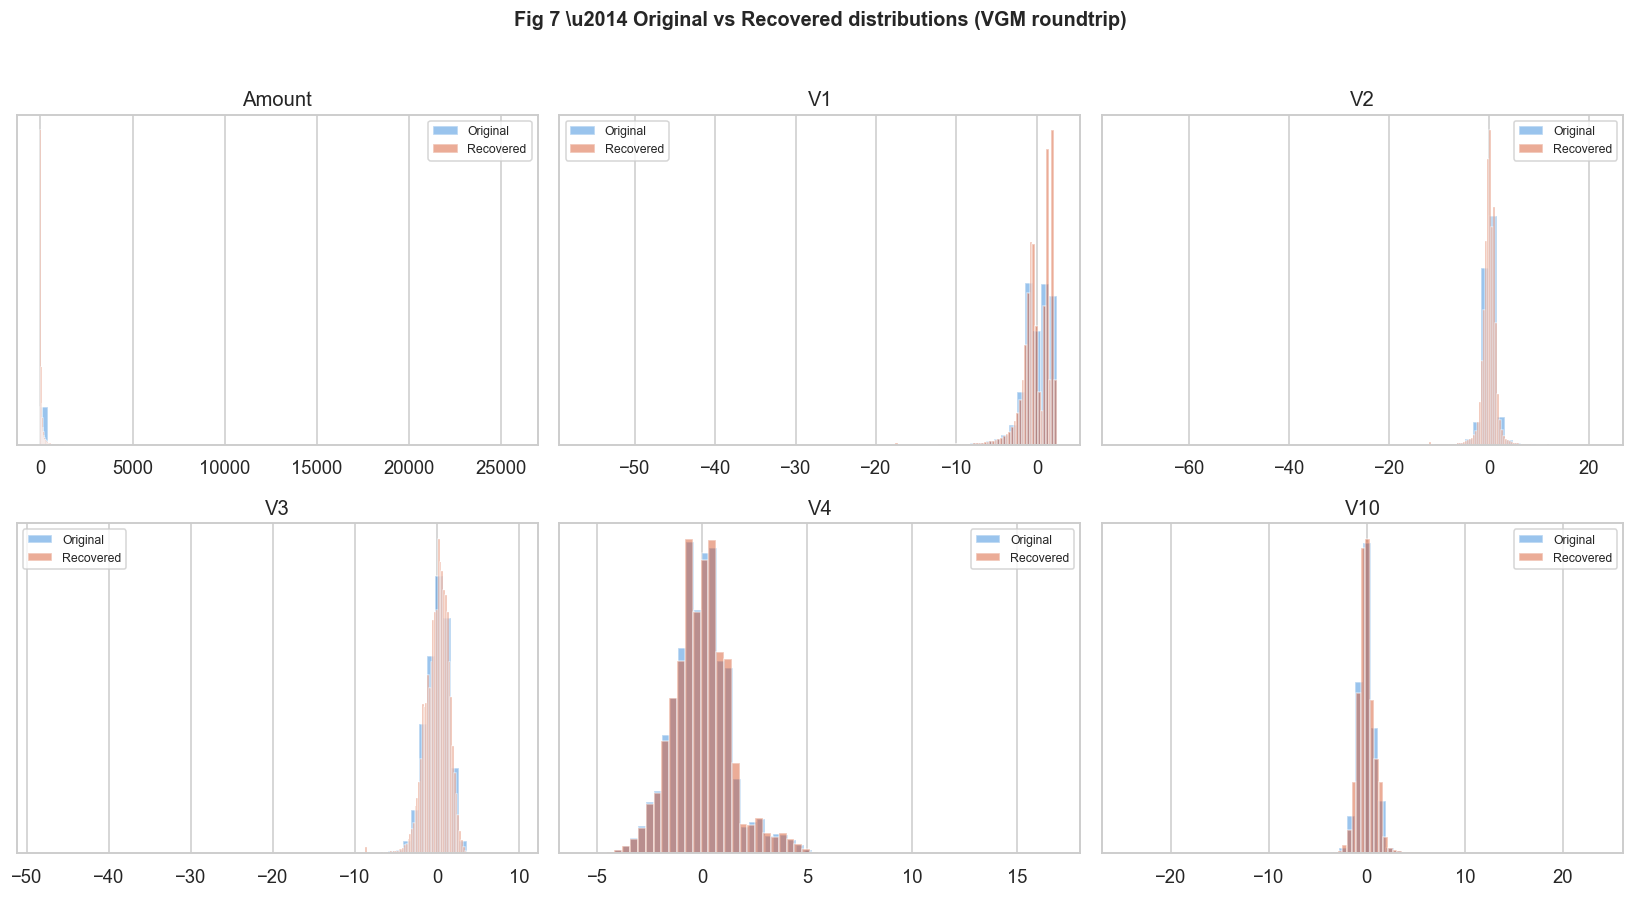

In [23]:
check_cols = ["Amount", "V1", "V2", "V3", "V4", "V10"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].hist(df[col],           bins=60, density=True,
                 color="#378ADD", alpha=0.5, label="Original")
    axes[i].hist(df_recovered[col], bins=60, density=True,
                 color="#D85A30", alpha=0.5, label="Recovered")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_yticks([])

plt.suptitle("Fig 7 \\u2014 Original vs Recovered distributions (VGM roundtrip)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig7_roundtrip_check.png", bbox_inches="tight")
plt.show()

## 11. Conditional Vector Analysis

Conditional vector \u2014 class totals:
Legit (0)    284315.0
Fraud (1)       492.0


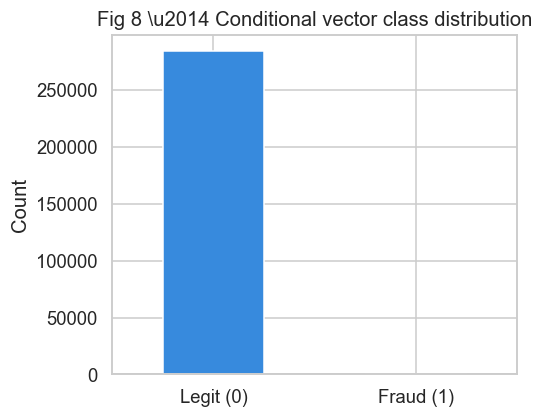

In [24]:
cond_df    = pd.DataFrame(cond_vec, columns=["Legit (0)", "Fraud (1)"])
class_dist = cond_df.sum()

print("Conditional vector \\u2014 class totals:")
print(class_dist.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
class_dist.plot(kind="bar", color=["#378ADD", "#D85A30"], ax=ax)
ax.set_title("Fig 8 \\u2014 Conditional vector class distribution")
ax.set_ylabel("Count")
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
plt.tight_layout()
plt.savefig("fig8_cond_vector.png", bbox_inches="tight")
plt.show()

## 12. Save Preprocessor + Tensors

In [25]:
import os
os.makedirs("../checkpoints", exist_ok=True)

prep.save("../checkpoints/preprocessor.pkl")
torch.save(data_tensor, "../checkpoints/data_tensor.pt")
np.save("../checkpoints/cond_vec.npy", cond_vec)

print("Saved:")
print("  \\u2713 ../checkpoints/preprocessor.pkl")
print("  \\u2713 ../checkpoints/data_tensor.pt")
print("  \\u2713 ../checkpoints/cond_vec.npy")
print("\nPreprocessor complete. Proceed to 03_model.ipynb")

Preprocessor saved \u2192 ../checkpoints/preprocessor.pkl
Saved:
  \u2713 ../checkpoints/preprocessor.pkl
  \u2713 ../checkpoints/data_tensor.pt
  \u2713 ../checkpoints/cond_vec.npy

Preprocessor complete. Proceed to 03_model.ipynb
